Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 45s 25ms/step - accuracy: 0.4174 - loss: 1.6383 - val_accuracy: 0.4424 - val_loss: 1.5937
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.5330 - loss: 1.3203 - val_accuracy: 0.5430 - val_loss: 1.2423
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.5865 - loss: 1.1844 - val_accuracy: 0.6366 - val_loss: 1.0308
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.6263 - loss: 1.0845 - val_accuracy: 0.5834 - val_loss: 1.2642
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.6447 - loss: 1.0226 - val_accuracy: 0.6027 - val_loss: 1.1891
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.6680 - loss: 0.9711 - val_accuracy: 0.6830 - val_loss: 0.9183
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.6790 - loss: 0.9350 - val_accuracy: 0.6774 - val_loss: 0.9995
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.6937 -

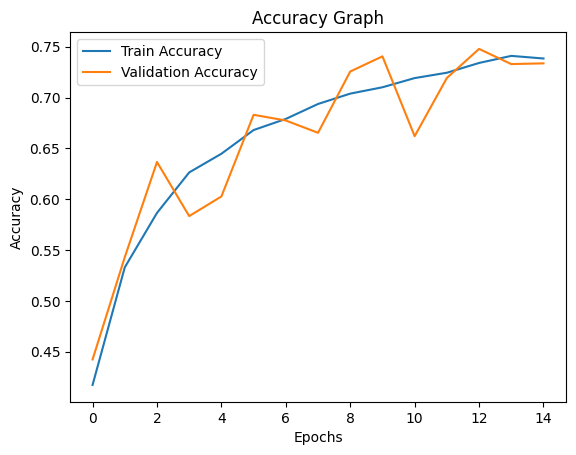

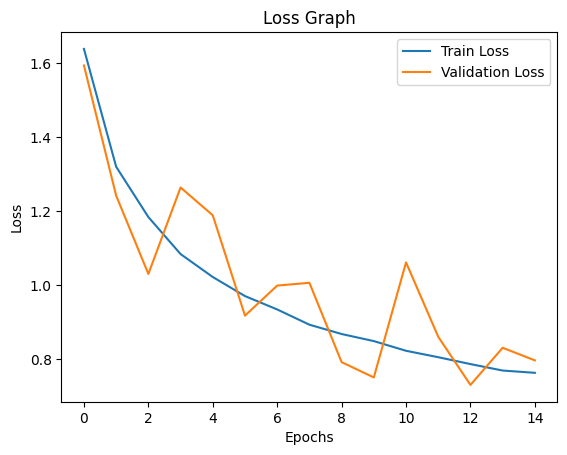

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Predicted: cat
Actual: cat


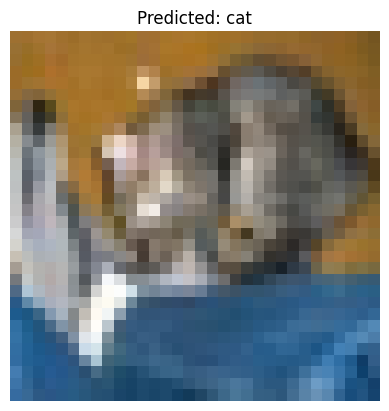

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator


(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()


train_images = train_images / 255.0
test_images = test_images / 255.0


datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

datagen.fit(train_images)


model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(10))
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

history = model.fit(
    datagen.flow(train_images, train_labels, batch_size=32),
    epochs=15,
    validation_data=(test_images, test_labels)
)


test_loss, test_acc = model.evaluate(test_images, test_labels)
print("Test Accuracy:", test_acc)


plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.show()

plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title("Loss Graph")
plt.show()


class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

predictions = model.predict(test_images)

predicted_label = np.argmax(predictions[0])
actual_label = test_labels[0][0]

print("Predicted:", class_names[predicted_label])
print("Actual:", class_names[actual_label])


plt.imshow(test_images[0])
plt.title(f"Predicted: {class_names[predicted_label]}")
plt.axis('off')
plt.show()